# Homework 4

## Task 2

**problem:**  
the task I've chosen is to predict next-hour PJM electricity demand based on a sequence of past hourly load data. A sequence model is required because the order of observations matters- electricity demand often fluctuates due to human activity cycles, weekday vs weekend behavior, and seasonal weather tendencies, with the formation of these patterns being a continuous process built by each subsequent observation. Each load instance is dependent on the time steps before it, i.e., exhibits temporal dependence, which RNNs are designed to handle.
<br>
<br>
**Dataset:**  
pjm_hourly_est.csv (PJM Hourly Energy Consumption Dataset) from https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption. Contains hourly electricity demand values for the PJM regional energy organization.
<br>
<br>
**RNN Framework:**  
PyTorch. Has built-in RNN, LSTM, and GRU layers.

### Part 1  
Implementing my RNN with PyTorch.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

#--------------------
# Load and preprocess
#--------------------
df = pd.read_csv("pjm_hourly_est.csv")
# convert all Datetime entries into actual datetime instances
df["Datetime"] = pd.to_datetime(df["Datetime"])
# we only need the datetime and pjm_load columns for this problem; the others are subloads
df = df[["Datetime", "PJM_Load"]]
# drop rows with missing target values and reset indexing
df = df.dropna().reset_index(drop=True)
# dataset is massive so just limiting to first 50,000 rows
df = df.iloc[:50000].copy()
# ensure dataset is properly ordered
df = df.sort_values(by="Datetime").reset_index(drop=True)

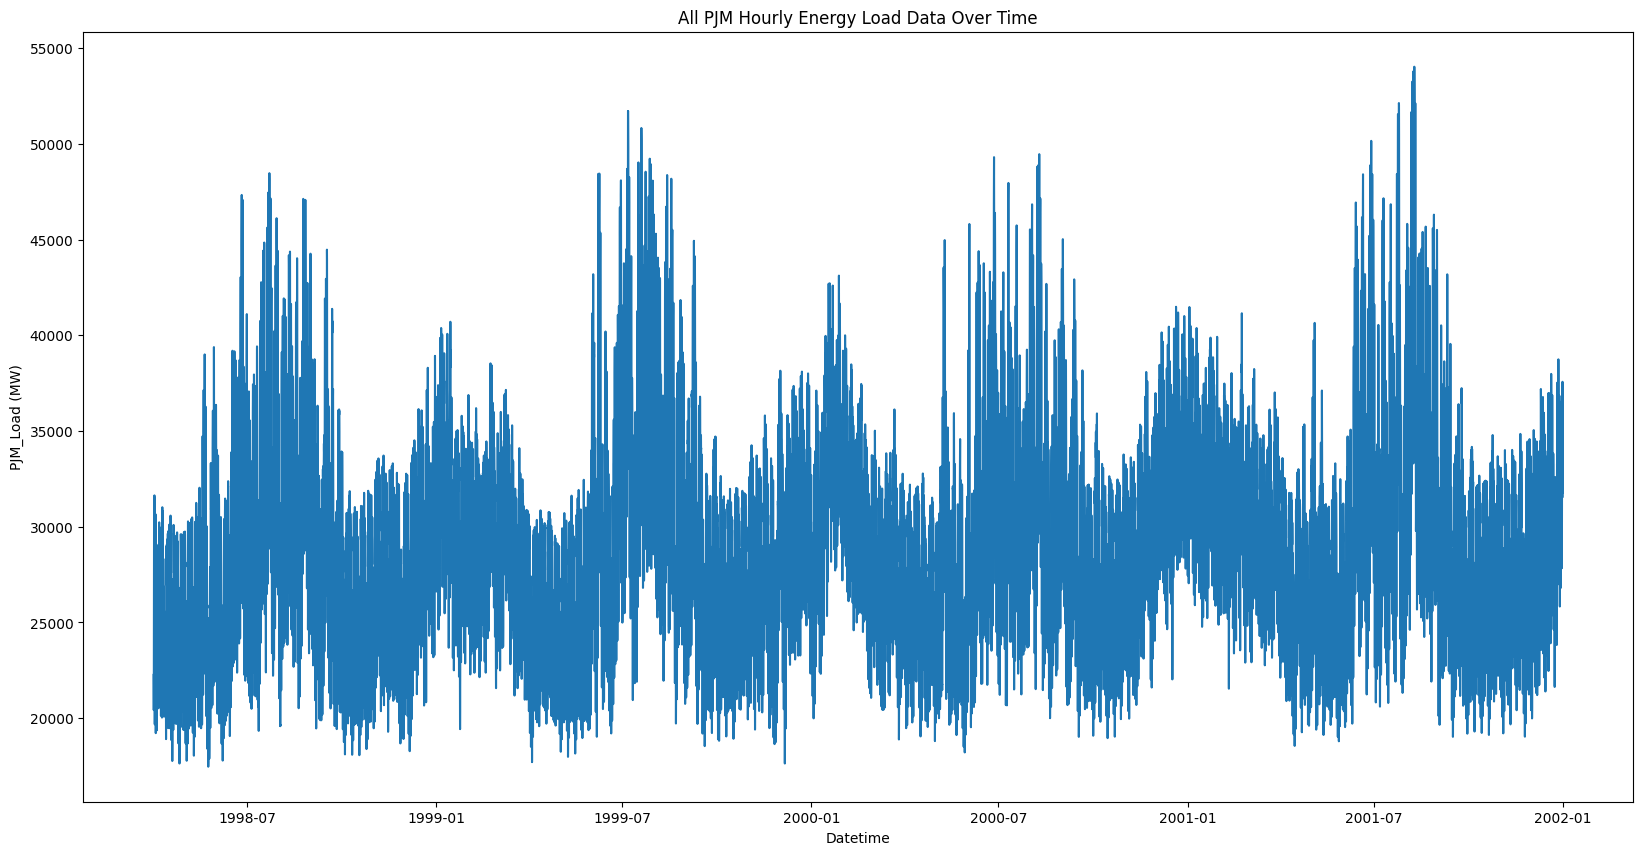

In [ ]:
#--------------------------
# Visualization of all data
#--------------------------
plt.figure(figsize=(20, 10))
plt.plot(df["Datetime"], df["PJM_Load"])
plt.title("All PJM Hourly Energy Load Data Over Time")
plt.xlabel("Datetime")
plt.ylabel("PJM_Load (MW)")
plt.show()

**Analysis**  
This visualizes load data for all 50,000 observations from mid 1998 to early 2002 broken into mid-year markers (July and January of each year). It shows peaks in energy usage occuring around July and lows occuring around the winter months, demonstrating strong seasonal patterns in electricity demand.

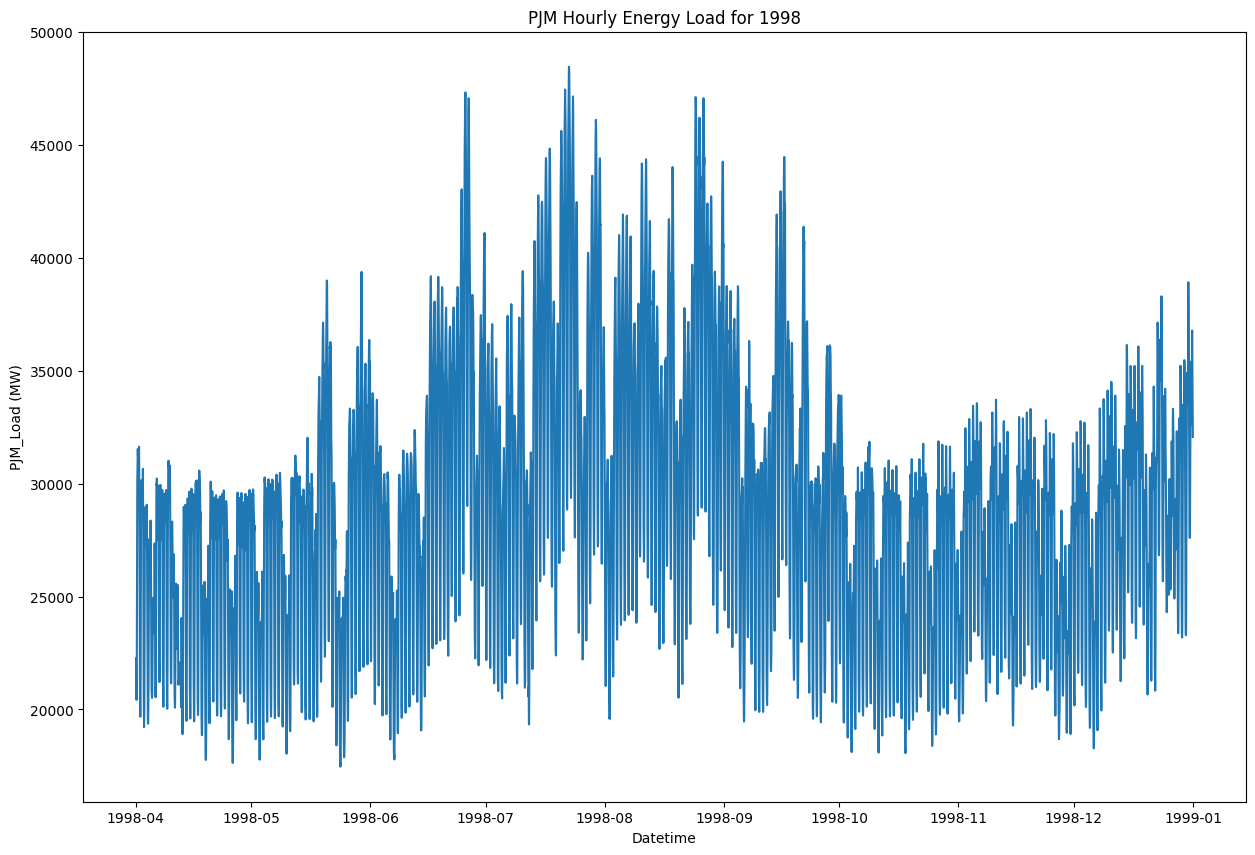

In [ ]:
#--------------------------
# Visualization of one year
#--------------------------
year = df[df["Datetime"].dt.year == 1998]
plt.figure(figsize=(15, 10))
plt.plot(year["Datetime"], year["PJM_Load"])
plt.title("PJM Hourly Energy Load for 1998")
plt.xlabel("Datetime")
plt.ylabel("PJM_Load (MW)")
plt.show()

**Analysis**  
Peak energy usage for the year 1998 occurs over the span of late June - late September, declines throughout the fall, then begins to approach another high in early January. This likely indicates a large usage of air conditioning and a reduced need for artificial lighting in the brightest and hottest months, a lull in demand during the milder seasons of spring and fall, and another spike in demand for heating and lighting in the winter, with dramatic spikes correlating to extreme heat and cold. There are wide variances within months that will be examined next.

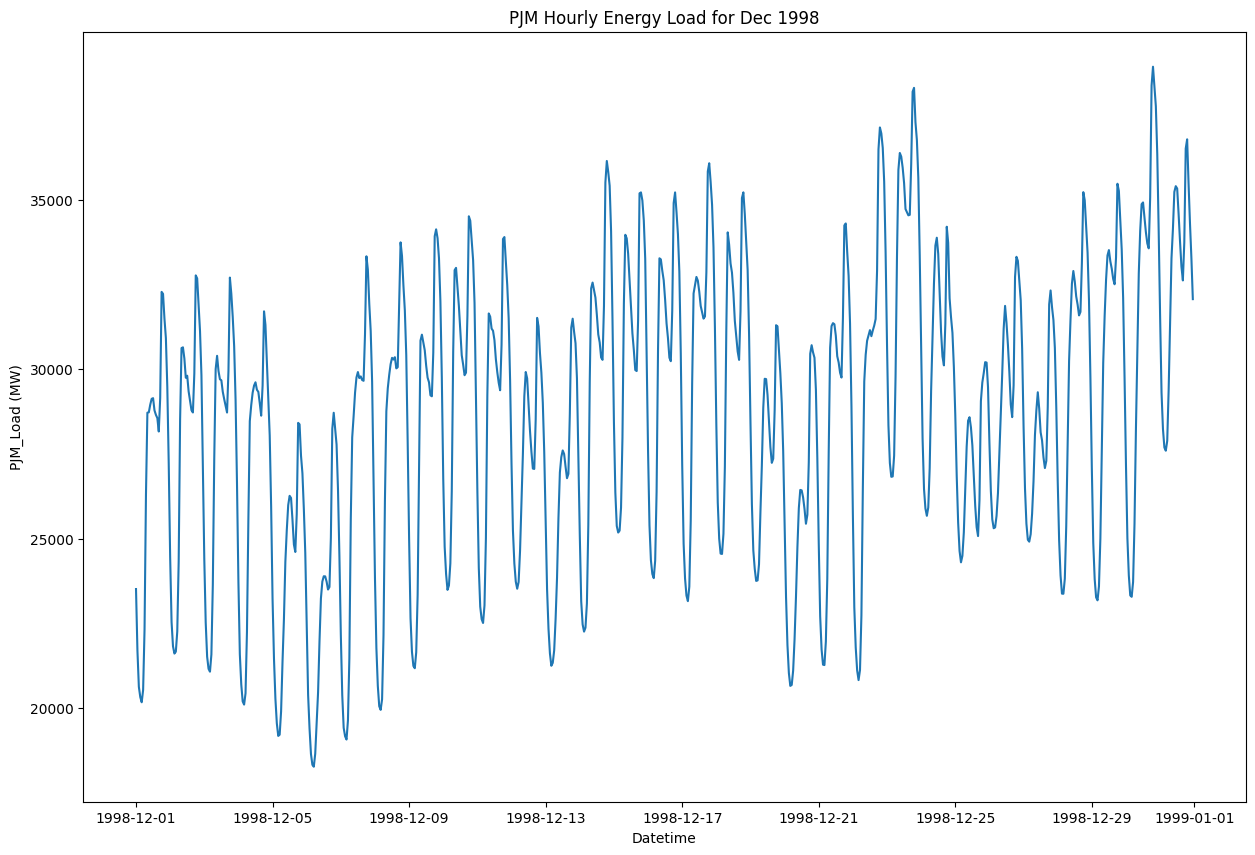

In [ ]:
#--------------------------
# Visualization of December 1998
#--------------------------
year = df[(df["Datetime"].dt.year == 1998) & (df["Datetime"].dt.month == 12)]
plt.figure(figsize=(15, 10))
plt.plot(year["Datetime"], year["PJM_Load"])
plt.title("PJM Hourly Energy Load for Dec 1998")
plt.xlabel("Datetime")
plt.ylabel("PJM_Load (MW)")
plt.show()

**Analysis**  
Energy demand sees a slight rise towards as the month progresses as days shorten and temperatures drop even more. There are strong and consistent highs and lows of energy usage each day, revealing daily cycles following human activity patterns. These patterns seem to closely follow a surge in the morning, slight drop throughout the day, peak at evening, then significant drop in the late night, which aligns well with typical 9-5 activity routines. Usage largely stays between 20000 and 40000 MW.


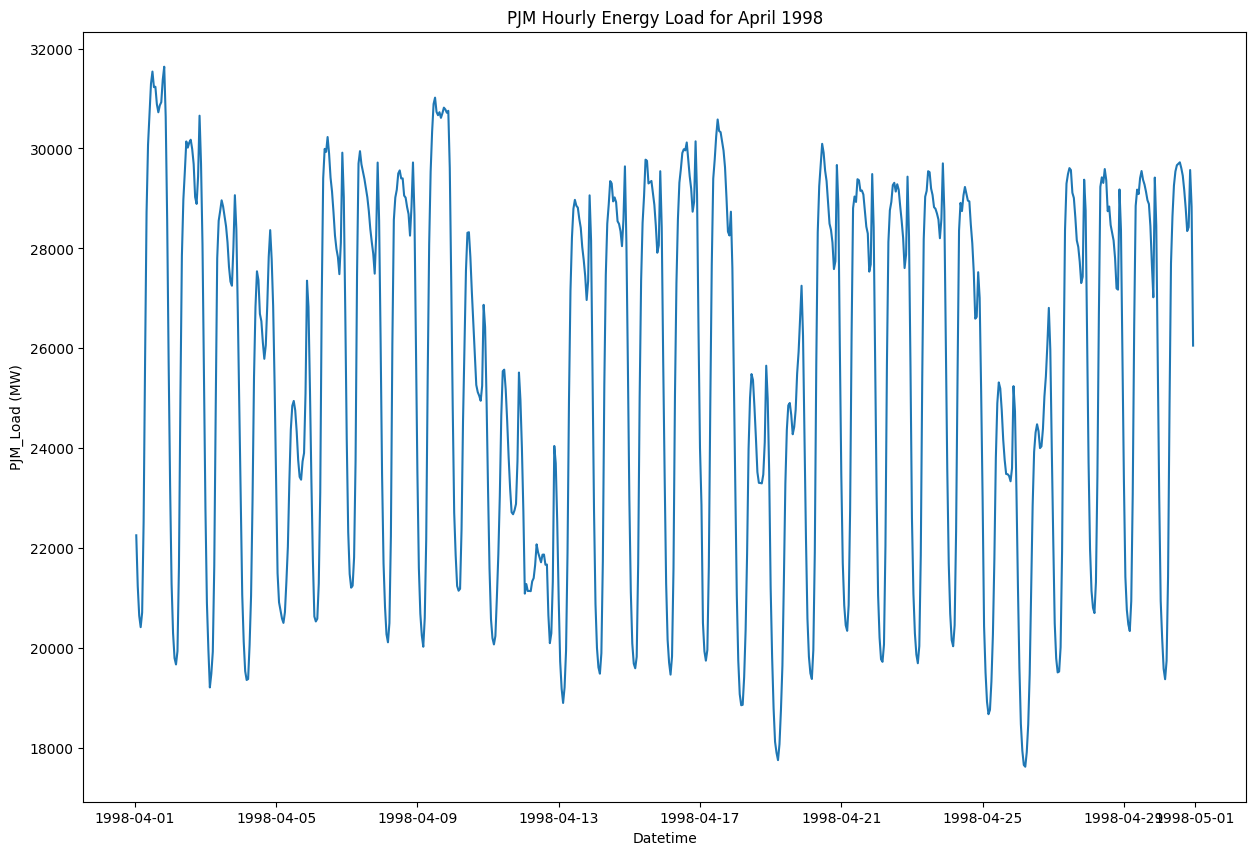

In [ ]:
#--------------------------
# Visualization of April 1998
#--------------------------
year = df[(df["Datetime"].dt.year == 1998) & (df["Datetime"].dt.month == 4)]
plt.figure(figsize=(15, 10))
plt.plot(year["Datetime"], year["PJM_Load"])
plt.title("PJM Hourly Energy Load for April 1998")
plt.xlabel("Datetime")
plt.ylabel("PJM_Load (MW)")
plt.show()

**Analysis**  
MW usage remains in a more similar range to that of December than I anticipated, also largely around 18,000 - 30000 with higher usage in the earlier part of the month likely due to lingering colder temperatures. Strong daily cycles are also evident. Load remains relatively consistent throughout the month.

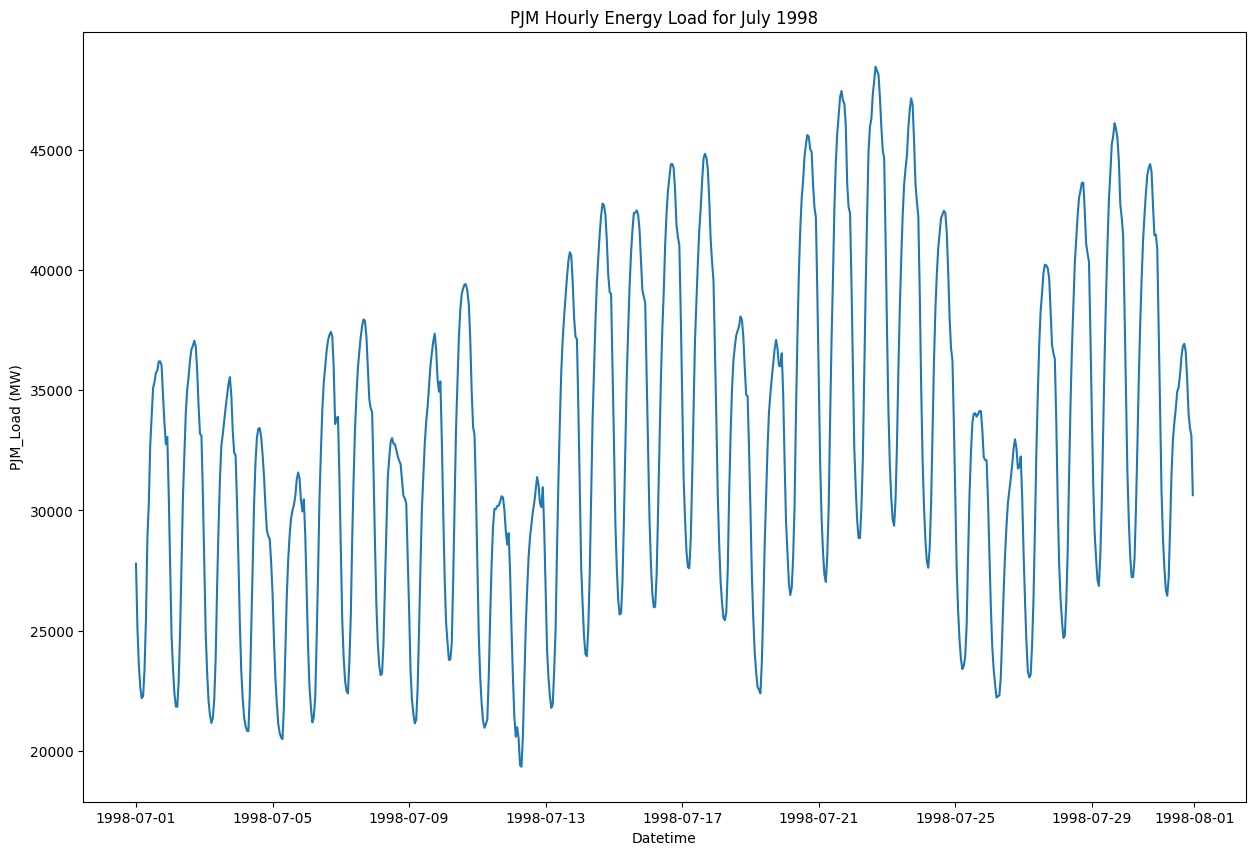

In [ ]:
#--------------------------
# Visualization of July 1998
#--------------------------
year = df[(df["Datetime"].dt.year == 1998) & (df["Datetime"].dt.month == 7)]
plt.figure(figsize=(15, 10))
plt.plot(year["Datetime"], year["PJM_Load"])
plt.title("PJM Hourly Energy Load for July 1998")
plt.xlabel("Datetime")
plt.ylabel("PJM_Load (MW)")
plt.show()

**Analysis**  
Noticeable increase in energy usage in later parts of the month, when temperatures warm. Strong daily cycles still remain, but follow a different pattern: as opposed to the two spikes in energy usage per day we'd been seeing in December and April, there is a smoother and more singular daily rise in usage preceding the usual late-night plummet. This could be indicative of schools being on summer recess, where households see more constant occupancy as opposed to when school and work are in session producing widespread vacancies around 9-5. Loads are significantly higher, inhabiting between 20000 and 45000 MW. It seems as though reaching 20000 MW in the late-night is a trend across all months.

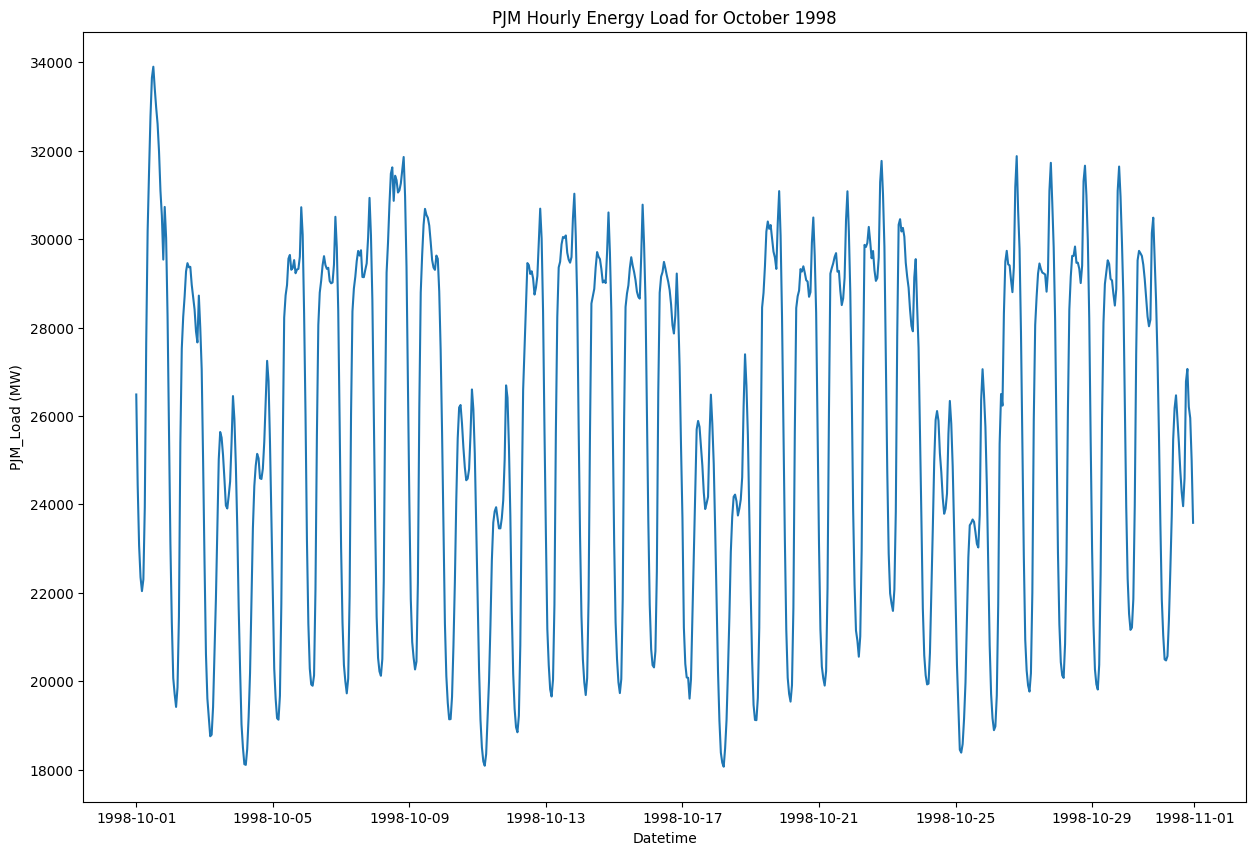

In [ ]:
#--------------------------
# Visualization of October 1998
#--------------------------
year = df[(df["Datetime"].dt.year == 1998) & (df["Datetime"].dt.month == 10)]
plt.figure(figsize=(15, 10))
plt.plot(year["Datetime"], year["PJM_Load"])
plt.title("PJM Hourly Energy Load for October 1998")
plt.xlabel("Datetime")
plt.ylabel("PJM_Load (MW)")
plt.show()

**Analysis**  
Usage returns to an even more moderate 18000 - 32000 range, indicative of mild temperatures. The typical twice-daily spike pattern returns.

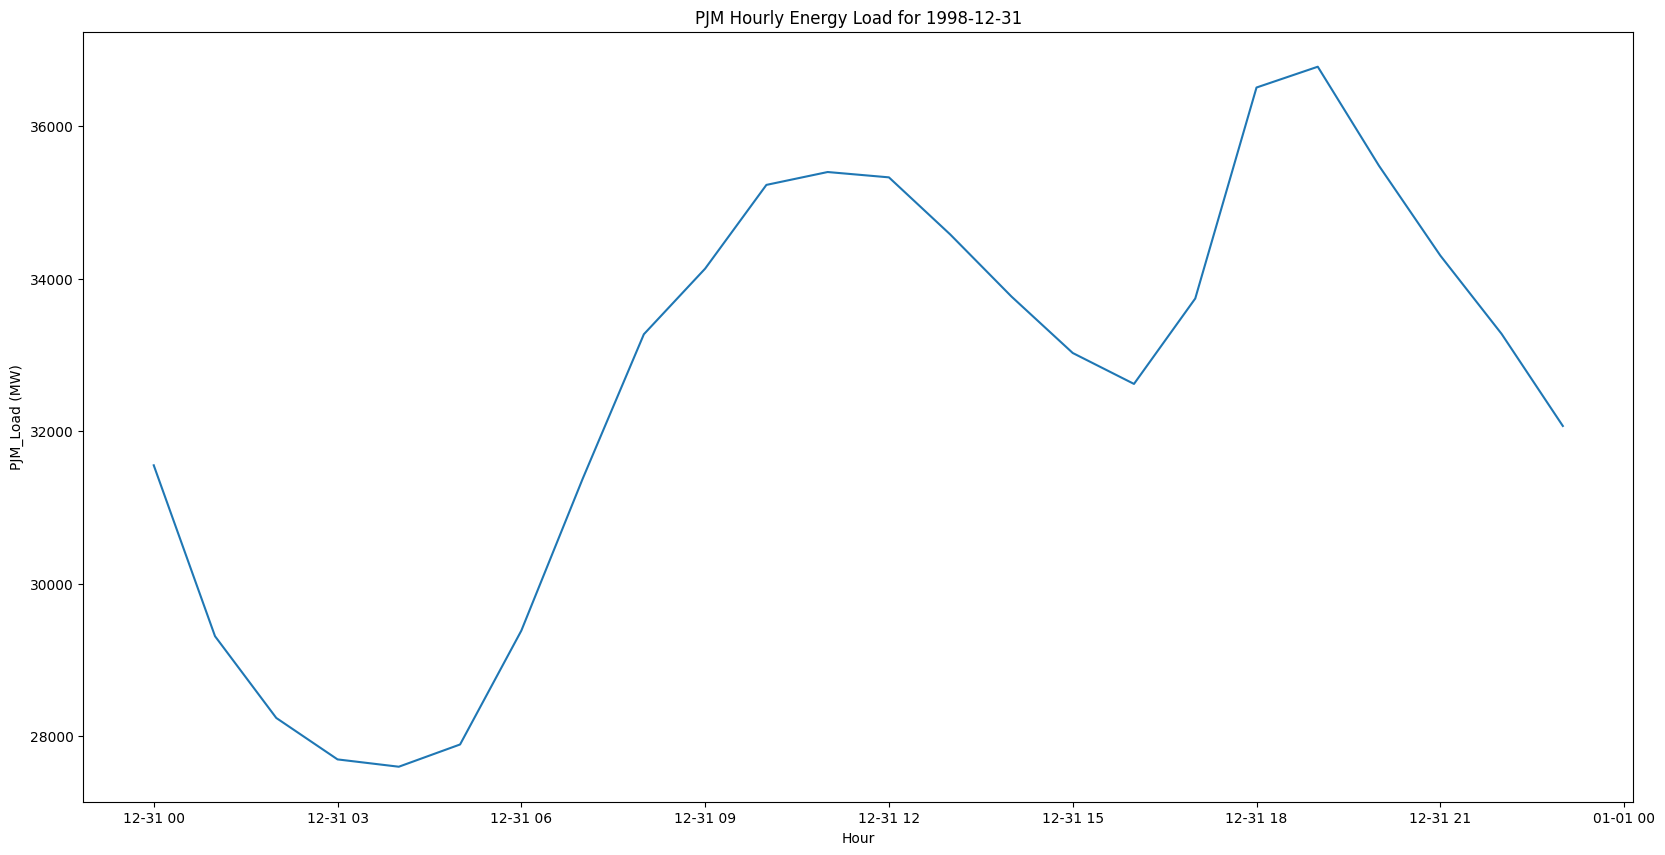

In [ ]:
#---------------------------------------------------
# Visualization of data from one specific winter day
#---------------------------------------------------
day = df[df["Datetime"].dt.date == pd.to_datetime("1998-12-31").date()]
plt.figure(figsize=(20, 10))
plt.plot(day["Datetime"], day["PJM_Load"])
plt.title("PJM Hourly Energy Load for 1998-12-31")
plt.xlabel("Hour")
plt.ylabel("PJM_Load (MW)")
plt.show()

**Analysis**  
Energy usage falls from 12 am to 3 am. Begins to pick up at 6 and sees a sharp incline until 9 am, where it plateaus until 12pm then decreases until 3 pm. It then increases sharply again until it peaks from 6-9pm, after which it plummets again. This confirms the pattern of a strong morning ramp, daytime plateau with an afternoon decrease, evening peak, then late-night drop. This corresponds with demand beginning to increase in the morning as people wake up and begin their daily routines, reaching highest levels during mid-morning. Then, the most prominent peak occurs in the evening, when families are back home and residents have the most prolonged activity before going to sleep, where household activities conclude.

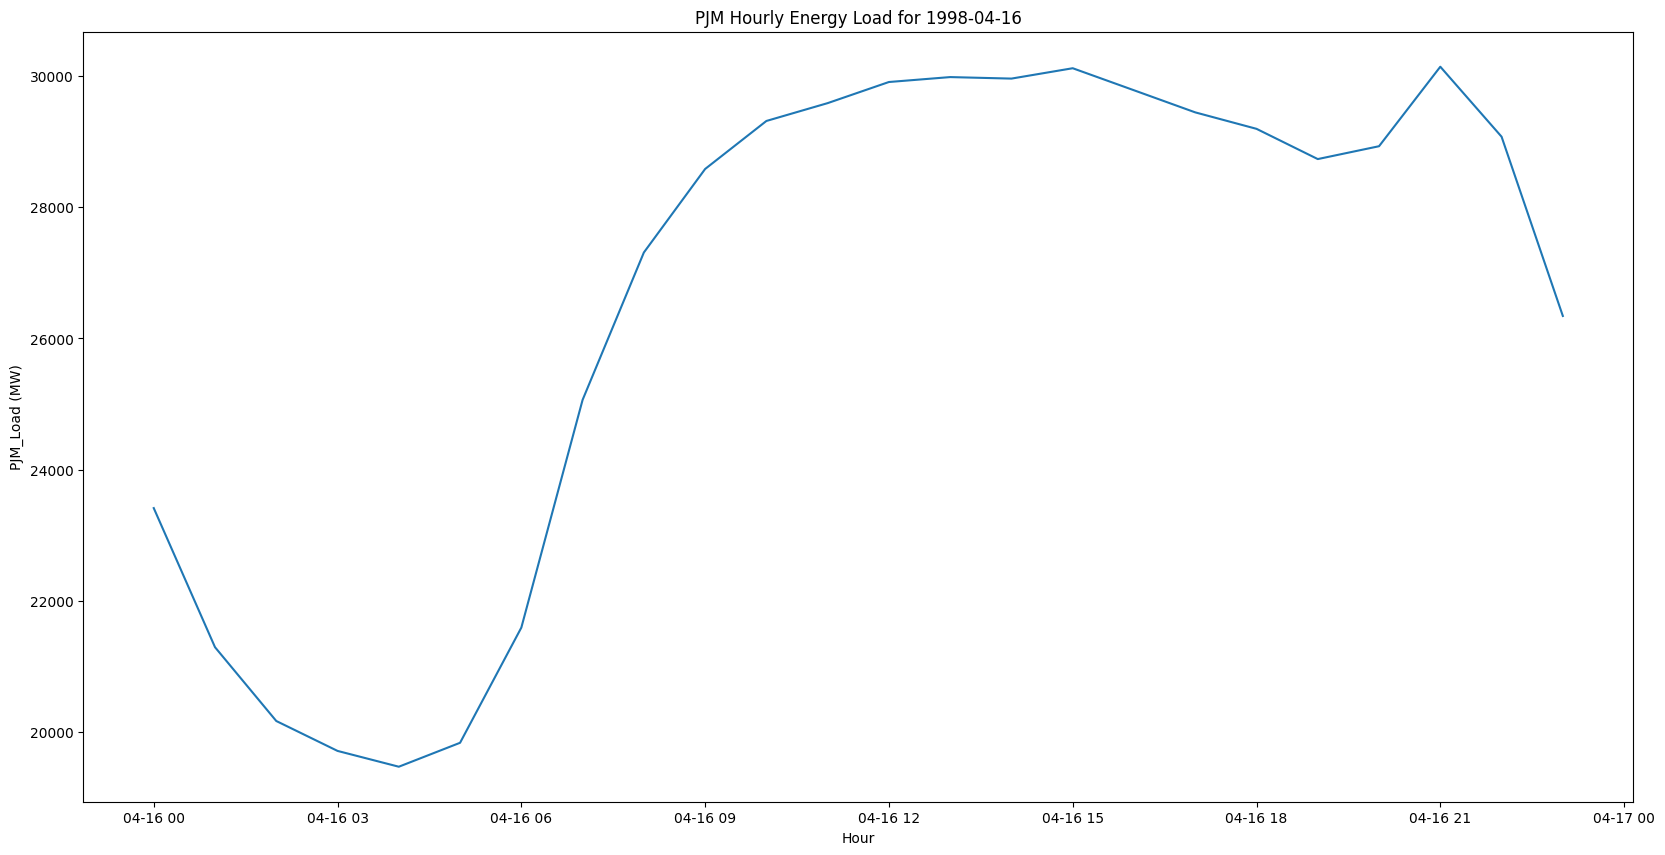

In [ ]:

#---------------------------------------------------
# Visualization of data from one specific spring day
#---------------------------------------------------
day = df[df["Datetime"].dt.date == pd.to_datetime("1998-04-16").date()]
plt.figure(figsize=(20, 10))
plt.plot(day["Datetime"], day["PJM_Load"])
plt.title("PJM Hourly Energy Load for 1998-04-16")
plt.xlabel("Hour")
plt.ylabel("PJM_Load (MW)")
plt.show()

**Analysis**  
The April curve shows lower overall demand than December with a smoother and flatter daily curve. This gradual change suggests extreme electricity loads are less common in milder spring weather. While it follows a similar pattern, the evening peak is milder. This could be because less heating and ac needed, people spending fewer time outdoors, less need for prolonged lighting (longer days), and fewer extreme weather events.

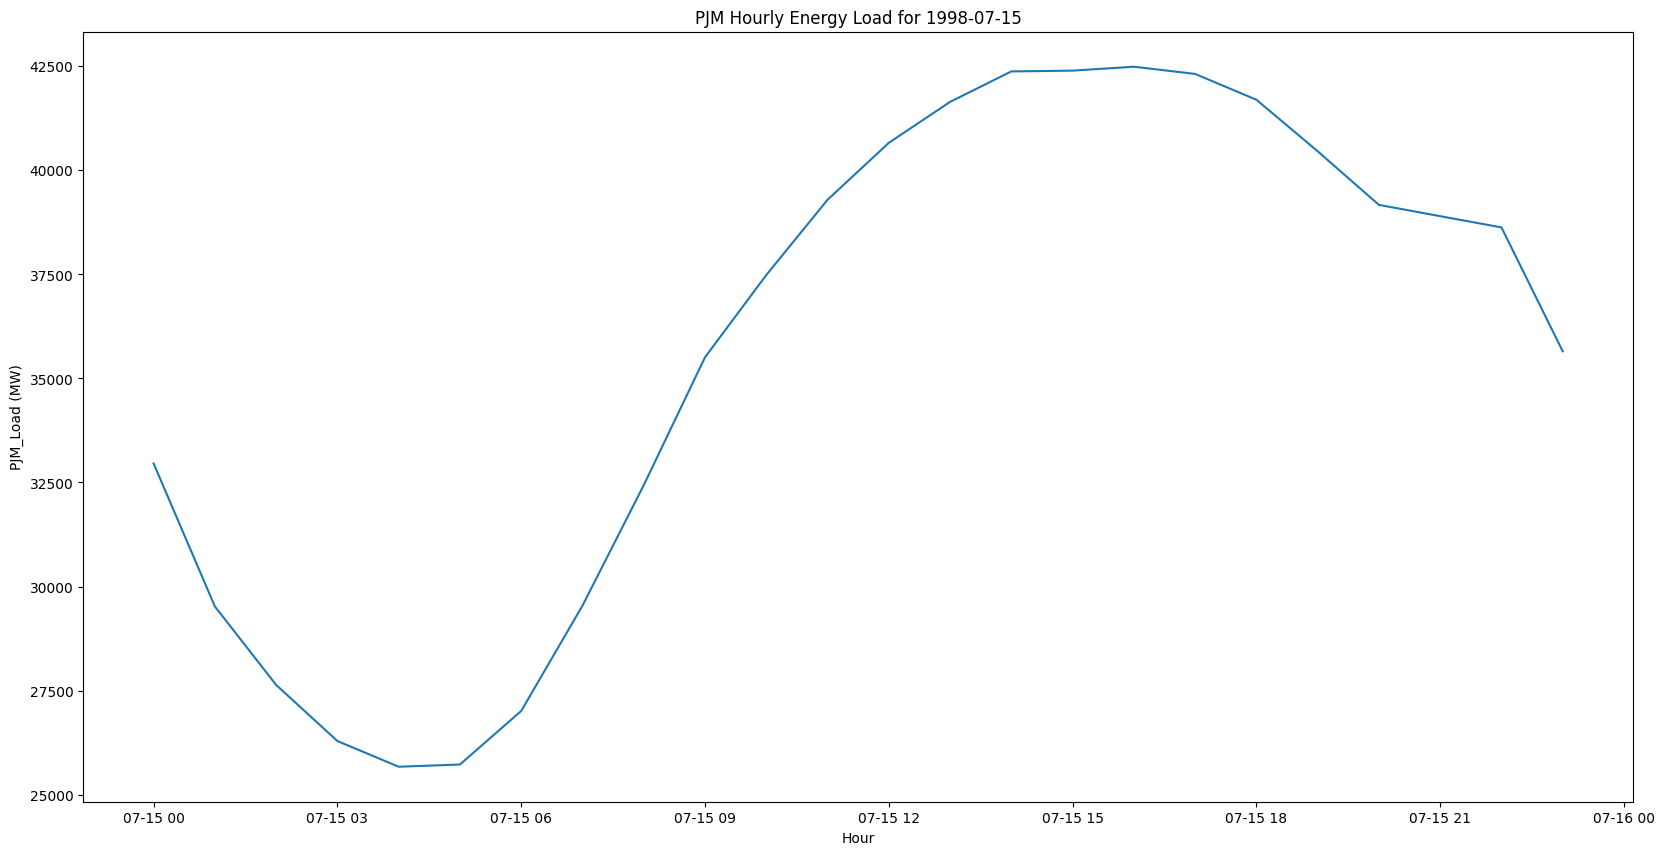

In [ ]:
#---------------------------------------------------
# Visualization of data from one specific summer day
#---------------------------------------------------
day = df[df["Datetime"].dt.date == pd.to_datetime("1998-07-15").date()]
plt.figure(figsize=(20, 10))
plt.plot(day["Datetime"], day["PJM_Load"])
plt.title("PJM Hourly Energy Load for 1998-07-15")
plt.xlabel("Hour")
plt.ylabel("PJM_Load (MW)")
plt.show()

**Analysis**  
Still follows a daily human activity cycle, but the peak magnitude is significantly higher than in April or December. Additionally, rather than in the evening, the July demand peaks in the afternoon, which corresponds to the hottest part of the day, where demand stays high for several hours. In summer, cooling systems tend to run continuously.

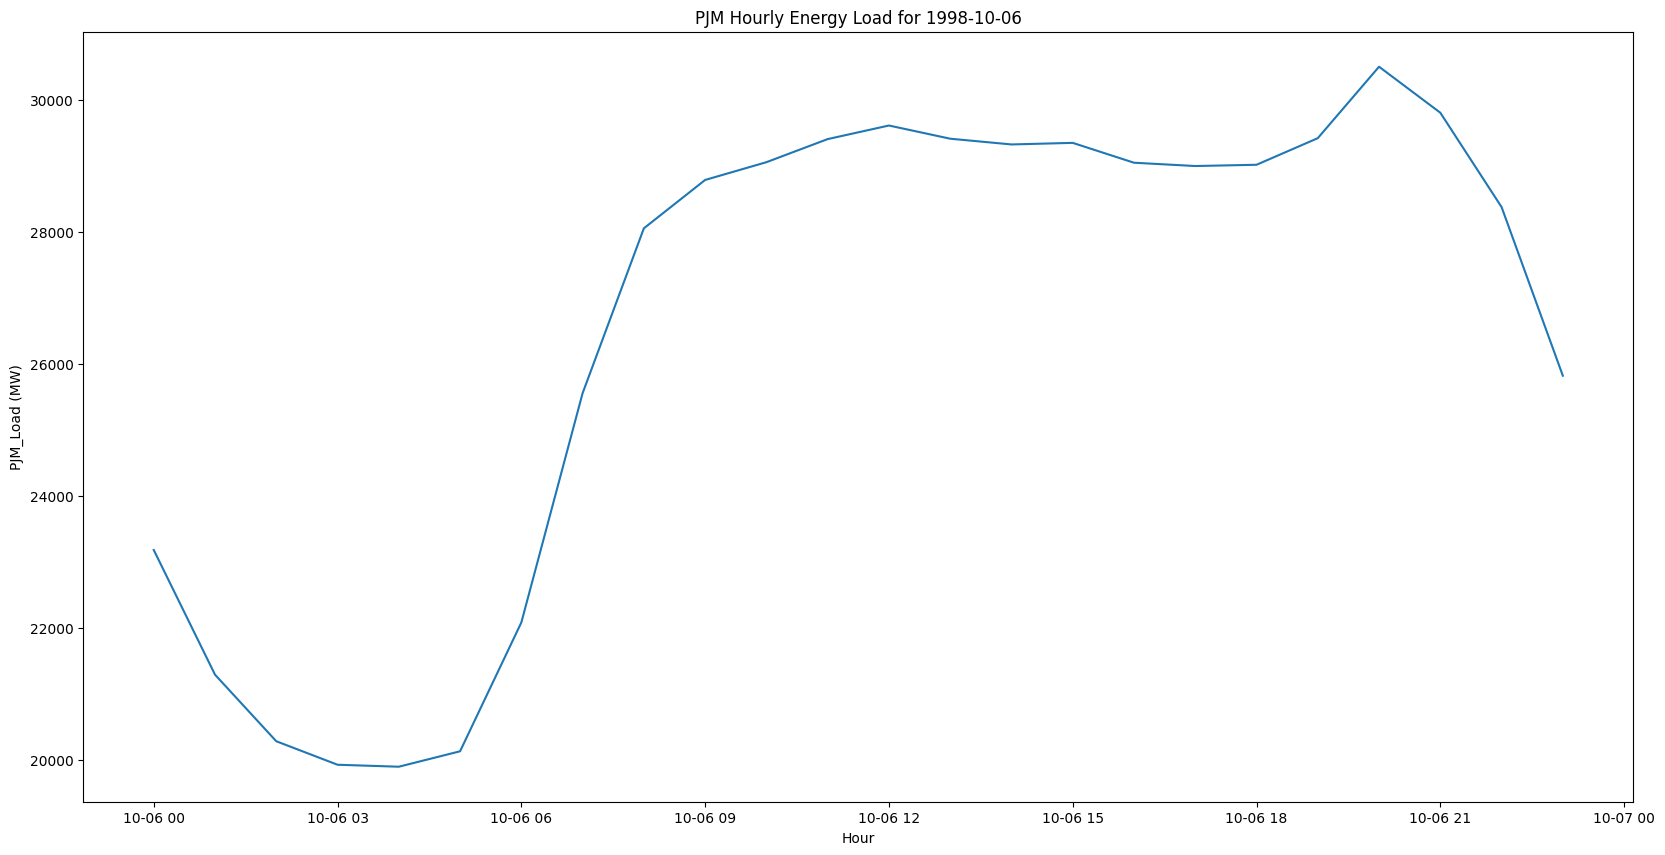

In [ ]:
#-------------------------------------------------
# Visualization of data from one specific fall day
#-------------------------------------------------
day = df[df["Datetime"].dt.date == pd.to_datetime("1998-10-06").date()]
plt.figure(figsize=(20, 10))
plt.plot(day["Datetime"], day["PJM_Load"])
plt.title("PJM Hourly Energy Load for 1998-10-06")
plt.xlabel("Hour")
plt.ylabel("PJM_Load (MW)")
plt.show()

**Analysis**  
Still follows daily activity pattern within a moderate overall demand. Evening peak returns.

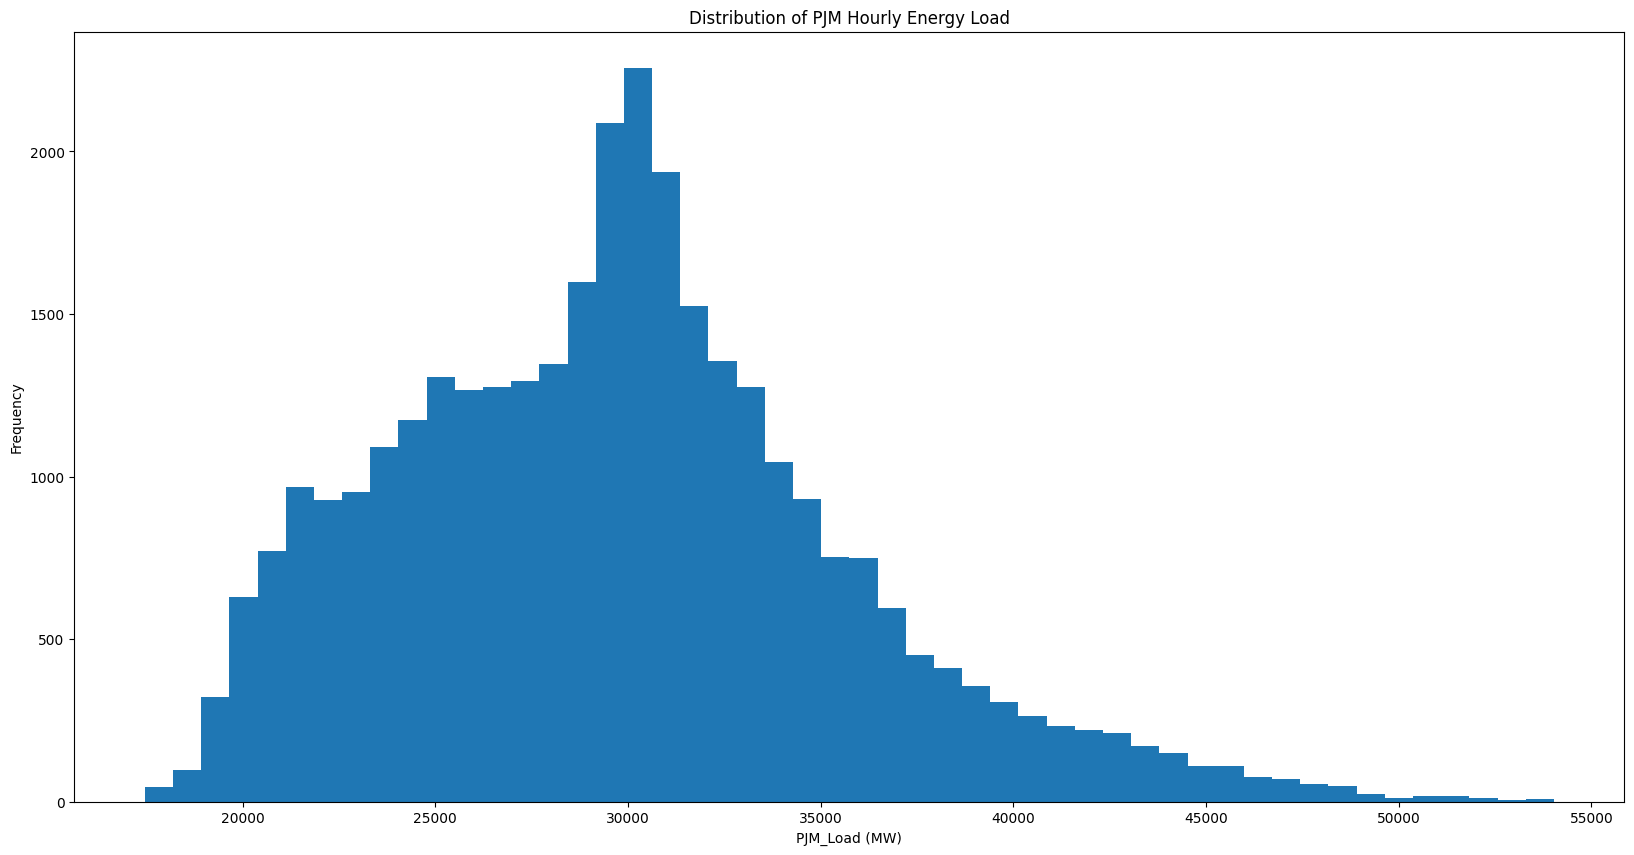

In [ ]:
#--------------------------------------
# Visualize distribution of load values
#--------------------------------------
plt.figure(figsize=(20, 10))
plt.hist(df["PJM_Load"], bins=50)
plt.title("Distribution of PJM Hourly Energy Load")
plt.xlabel("PJM_Load (MW)")
plt.ylabel("Frequency")
plt.show()

**Analysis**  
Most demand values cluster around 32,000, with the peak/most common at about 30000. The distribution is right-skewed with a long tail towards higher load values up to around 55000. Low demand values below 20000 are less frequent. Range is roughly 18000 to 55000 and has an approximately bell-shaped distribution. This is a large range so I will scale it with MinMaxScaler before feeding it into the RNN. I chose MinMaxScaler because it shrinks the values into a clean, small range without changing the pattern of the data.

In [ ]:
#-------------------------
# scale with MinMaxScaler()
#-------------------------

scaler = MinMaxScaler()
df["PJM_scaled"] = scaler.fit_transform(df[["PJM_Load"]])

#----------------------
# Create time sequences
#----------------------

# choosing sequence length of 24 time-stamps because 24-hour windows capture the full daily cycles of energy usage
sequence_length = 24
X = []
y = []
data = df["PJM_scaled"].values

for i in range(len(data) - sequence_length):
  X.append(data[i:i+sequence_length]) # the input data is each block of 24 observations
  y.append(data[i+sequence_length]) # the target variable is the very next observation after the sequence

X = np.array(X) # (32872, 24)
y = np.array(y) # (32872,)
# RNNs need input shape (batch_size, sequence_length, input_size), so must reshape to (32872, 24, 1)
X = X.reshape(X.shape[0], X.shape[1], 1) # each time step only has one feature so input_size = 1

#-----------
# Split data
#-----------
# train: 70%. Val: 15%. Test: 15%
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X)) # these are just sizes, not indices

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size] # must add size to current index to get final index
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

#-------------------
# Convert to PyTorch
#-------------------
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1) # reshape to (numsamples, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1,1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

batch_size = 64 # stable size

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
#-----------------------
# Defining the basic RNN
#-----------------------
class BasicRNN(nn.Module):
  # input_size: number of features at each time step in the sequence (1)
  # hidden_size: 32 internal memory slots to encode paterns from previous time steps
  # num_layers: single layer RNN: input --> RNN --> output layer
  # output_size: 1, predicting next one-hour load
  def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
    super(BasicRNN, self).__init__() # call parent constructor nn.Module
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    # creates the basic rnn layer
    self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, nonlinearity='tanh') # tanh is standard activation function for rnn
    # create fully connected output layer: convert final hidden representation into final prediction
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    # hidden-state output for each time step in the sequence, final hidden state after the last time step
    out, hn = self.rnn(x)
    out = out[:, -1, :] # keep only the output from the last step
    # pass final hidden representation into a fully connected layer, maps 32 hidden features --> 1 predicted load
    out = self.fc(out)
    return out # final predicted load number

#-------
# set up
#-------
model = BasicRNN(input_size=1, hidden_size=32, num_layers=1, output_size=1)
loss_function = nn.MSELoss() # using MSE because for regression
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Adam is strong default optimizer, lr is stable default value

In [ ]:
from torch.nn.modules import loss
#------------------------
# Training and validation
#------------------------

# function to measure how well trained model performs on validation and test sets
# model: trained RNN model
# loader: dataset loader (validation or test)
# loss_function: loss metric (MSE)
def evaluate_model(model, loader, loss_function):
  model.eval() # set model to evaluation mode
  # initialize vars
  total_loss = 0.0 # used to compute average loss over the whole dataset
  preds = [] # stores the model's predictions
  actuals = [] # stores the true values from the dataset
  with torch.no_grad(): # disable gradient tracking
    for X_batch, y_batch in loader:
      # make predictions
      outputs = model(X_batch)
      # compute loss
      loss = loss_function(outputs, y_batch)
      # calculate and store total loss
      total_loss += loss.item() * X_batch.size(0)
      # store predictions (ensure CPU, required for numpy)
      preds.extend(outputs.cpu().numpy())
      # store actual values
      actuals.extend(y_batch.cpu().numpy())
  # compute average loss
  avg_loss = total_loss / len(loader.dataset)
  # convert all lists to arrays
  preds = np.array(preds)
  actuals = np.array(actuals)
  # return average loss, predicted values, actual values
  return avg_loss, preds, actuals

num_epochs = 20 # moderate number of passes
# store losses for train and val sets
train_losses = []
val_losses = []

# run training loop
for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0

  for X_batch, y_batch in train_loader:
    optimizer.zero_grad() # reset gradients from previous batch
    # forward prop
    outputs = model(X_batch)
    loss = loss_function(outputs, y_batch)
    # backprop
    loss.backward()
    # update model weights using Adam
    optimizer.step()
    # calculate and add total training loss
    running_loss += loss.item() * X_batch.size(0)

  # average training loss across entire dataset
  train_loss = running_loss / len(train_loader.dataset)
  # get average val loss
  val_loss, _, _ = evaluate_model(model, val_loader, loss_function)
  train_losses.append(train_loss)
  val_losses.append(val_loss)

  print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


Epoch 1/20, Train Loss: 0.0067, Val Loss: 0.0027
Epoch 2/20, Train Loss: 0.0018, Val Loss: 0.0016
Epoch 3/20, Train Loss: 0.0013, Val Loss: 0.0011
Epoch 4/20, Train Loss: 0.0009, Val Loss: 0.0007
Epoch 5/20, Train Loss: 0.0006, Val Loss: 0.0005
Epoch 6/20, Train Loss: 0.0005, Val Loss: 0.0004
Epoch 7/20, Train Loss: 0.0004, Val Loss: 0.0004
Epoch 8/20, Train Loss: 0.0004, Val Loss: 0.0004
Epoch 9/20, Train Loss: 0.0004, Val Loss: 0.0004
Epoch 10/20, Train Loss: 0.0003, Val Loss: 0.0004
Epoch 11/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 12/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 13/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 14/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 15/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 16/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 17/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 18/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 19/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 20/20, Train Loss: 0.0003, Val Loss: 0.0003


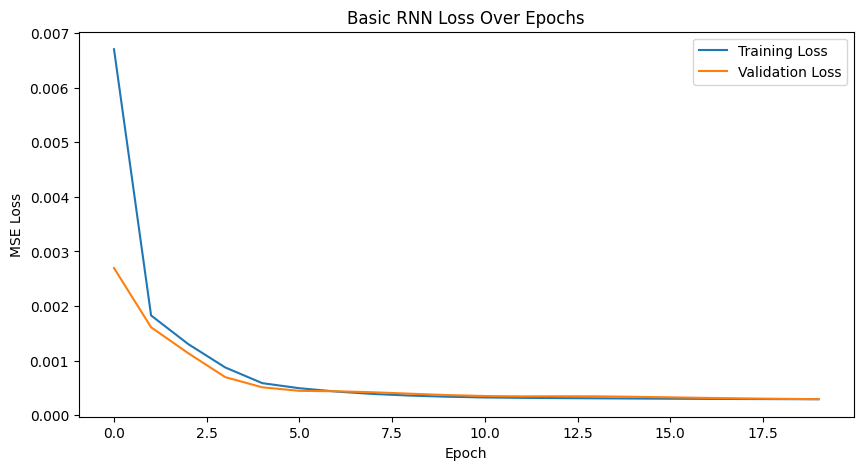

In [ ]:
#-----------------
# Plot loss curves
#-----------------

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label = "Validation Loss")
plt.title("Basic RNN Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

**Analysis**  
Demonstrates rapid initial learning where both training and val losses drop sharply within in the first ~4 epochs, so the model is able to quickly learn the dominant structure of the data. The losses converge around epoch 8, stabilizing at about 0.0003, which means additional epochs produce minimal improvement. The two curves are also very close, demonstrating minimal overfitting and good generalization. Curves are relatively smooth and stable.

In [ ]:
#-------------------------------------
# Evaluate on metrics (MSE, RMSE, MAE)
#-------------------------------------

# validation predictions
val_loss, val_preds_scaled, val_actuals_scaled = evaluate_model(model, val_loader, loss_function)
# test predictions
test_loss, test_preds_scaled, test_actuals_scaled = evaluate_model(model, test_loader, loss_function)
# convert predictions back to original units (MW)
val_preds = scaler.inverse_transform(val_preds_scaled)
val_actuals = scaler.inverse_transform(val_actuals_scaled)
test_preds = scaler.inverse_transform(test_preds_scaled)
test_actuals = scaler.inverse_transform(test_actuals_scaled)

val_mse = mean_squared_error(val_actuals, val_preds)
val_rmse = np.sqrt(val_mse)
val_mae = mean_absolute_error(val_actuals, val_preds)

test_mse = mean_squared_error(test_actuals, test_preds)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(test_actuals, test_preds)

print("Validation Metrics:")
print(f"MSE: {val_mse:.4f}")
print(f"RMSE: {val_rmse:.4f}")
print(f"MAE: {val_mae:.4f}")

print("\nTest Metrics:")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")

Validation Metrics:
MSE: 390640.7188
RMSE: 625.0126
MAE: 446.3667

Test Metrics:
MSE: 413772.0000
RMSE: 643.2511
MAE: 473.0662


**Analysis:**  
RMSE and MAE provide more meaningful measurements due to unit alignment. On average, the model's predictions are about 470 MW away from teh true electricity demand (MAE). When we account for occasional larger prediction mistakes, the error rises to around 640 MW (RMSE). The relative error is very small, and there is a very small difference between the validation and the test RMSE and MAE. RMSE being larger than MAE suggests the model can make larger errors during unusual demand spikes.

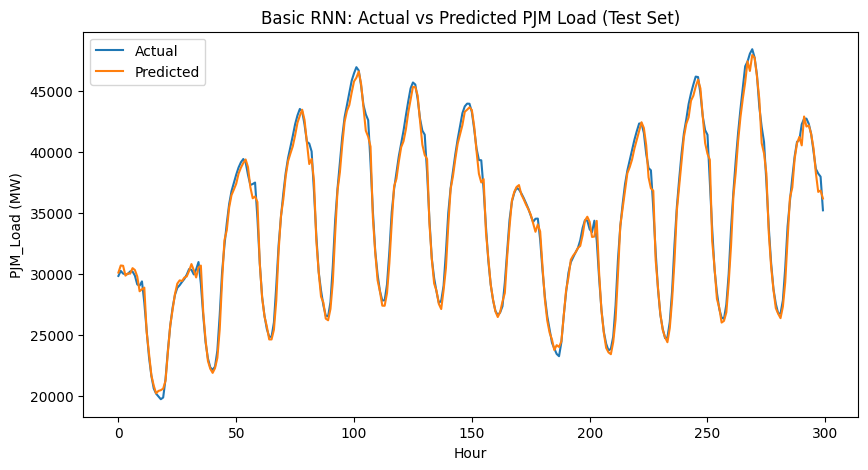

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(test_actuals[:300], label ="Actual")
plt.plot(test_preds[:300], label="Predicted")
plt.title("Basic RNN: Actual vs Predicted PJM Load (Test Set)")
plt.xlabel("Hour")
plt.ylabel("PJM_Load (MW)")
plt.legend()
plt.show()

**Analysis**  
The predicted line (orange) follows the actual line (blue) nearly perfectly with small errors near extreme values, indicating the basic RNN successfully learned the repeating patterns in hourly electricity demand aside from occasionally smoothing sharp spikes.

**RNN Structure**  

I implemented a basic RNN using PyTorch's nn.RNN module. The inputs of the model are a sequence of 24 previous hourly load values, where each time step contains PJM_Load as the only feature. The RNN processesses the sequence one step at a time and maintains a hidden state that carries learned patterns from earlier time steps. The final hidden representation from the last time step is passed to a fully connected linear layer to predict the next hour's electricity demand.
<br>
- input size = 1
- sequence length = 24
- hidden size = 32
- number of layers = 1
- output size = 1  
<br>

**Activation Functions**  
I use the tanh activation function for the hidden state transitions because it's standard and effective for RNNs. The output layer is a fully connected linear layer with no activation function (or just Linear) because this is a regression problem where the model must predict a continuous load value rather than a class probability, so we don't want the range of predicted values to be reduced.  
<br>

**Performance Metric**  
I use MSE as the loss function during training because it's convenient for neural networks, as it penalizes larger mistakes and makes the function smooth for gradient descent. To interpret performance, I primarily used RMSE and MAE because they produce the prediction errors in the same units as the original electricity load, and they provide helpful values that measure how much the model's predictions are off by on average and durimg umusual spikes.


### Part 2

In [ ]:
#-----------
# LSTM Model
#-----------
class LSTMModel(nn.Module):
  # input_size: number of features at each time step in the sequence (1)
  # hidden_size: 32 internal memory slots to encode paterns from previous time steps
  # num_layers: single layer RNN: input --> RNN --> output layer
  # output_size: 1, predicting next one-hour load
  def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
    super(LSTMModel, self).__init__() # call parent constructor nn.Module
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    # creates the basic rnn layer
    self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
    # create fully connected output layer: convert final hidden representation into final prediction
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    out, (hn, cn) = self.lstm(x) # hidden state (short term) and cell state (long term)
    out = out[:, -1, :] # keep only the output from the last step
    # pass final hidden representation into a fully connected layer, maps 32 hidden features --> 1 predicted load
    out = self.fc(out)
    return out # final predicted load number

In [ ]:
#----------
# GRU Model
#----------

class GRUModel(nn.Module):
  # input_size: number of features at each time step in the sequence (1)
  # hidden_size: 32 internal memory slots to encode paterns from previous time steps
  # num_layers: single layer RNN: input --> RNN --> output layer
  # output_size: 1, predicting next one-hour load
  def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
    super(GRUModel, self).__init__() # call parent constructor nn.Module
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    # creates the basic rnn layer
    self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
    # create fully connected output layer: convert final hidden representation into final prediction
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    # hidden-state output for each time step in the sequence, final hidden state after the last time step
    out, hn = self.gru(x)
    out = out[:, -1, :] # keep only the output from the last step
    # pass final hidden representation into a fully connected layer, maps 32 hidden features --> 1 predicted load
    out = self.fc(out)
    return out # final predicted load number

In [ ]:
#-------------
# Train models
#-------------

def train_model(model, train_loader, val_loader, loss_function, optimizer, num_epochs=20):
  train_losses = []
  val_losses = []
  for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
      optimizer.zero_grad()
      outputs = model(X_batch)
      loss = loss_function(outputs, y_batch)
      loss.backward()
      optimizer.step()
      running_loss += loss.item() * X_batch.size(0)
    train_loss = running_loss / len(train_loader.dataset)
    val_loss, _, _ = evaluate_model(model, val_loader, loss_function)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
  return train_losses, val_losses

#-----------
# Train LSTM
#-----------
lstm_model = LSTMModel(input_size=1, hidden_size=32, num_layers=1, output_size=1)
loss_function = nn.MSELoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
lstm_train_losses, lstm_val_losses = train_model(lstm_model, train_loader, val_loader, loss_function, lstm_optimizer, num_epochs=20)

#----------
# Train GRU
#----------
gru_model = GRUModel(input_size=1, hidden_size=32, num_layers=1, output_size=1)
gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)
gru_train_losses, gru_val_losses = train_model(gru_model, train_loader, val_loader, loss_function, gru_optimizer, num_epochs=20)

Epoch 1/20, Train Loss: 0.0178, Val Loss: 0.0118
Epoch 2/20, Train Loss: 0.0051, Val Loss: 0.0035
Epoch 3/20, Train Loss: 0.0020, Val Loss: 0.0019
Epoch 4/20, Train Loss: 0.0015, Val Loss: 0.0016
Epoch 5/20, Train Loss: 0.0012, Val Loss: 0.0012
Epoch 6/20, Train Loss: 0.0010, Val Loss: 0.0010
Epoch 7/20, Train Loss: 0.0007, Val Loss: 0.0008
Epoch 8/20, Train Loss: 0.0006, Val Loss: 0.0005
Epoch 9/20, Train Loss: 0.0004, Val Loss: 0.0004
Epoch 10/20, Train Loss: 0.0004, Val Loss: 0.0004
Epoch 11/20, Train Loss: 0.0003, Val Loss: 0.0004
Epoch 12/20, Train Loss: 0.0003, Val Loss: 0.0004
Epoch 13/20, Train Loss: 0.0003, Val Loss: 0.0004
Epoch 14/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 15/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 16/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 17/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 18/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 19/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 20/20, Train Loss: 0.0003, Val Loss: 0.0003
Epoch 1/2

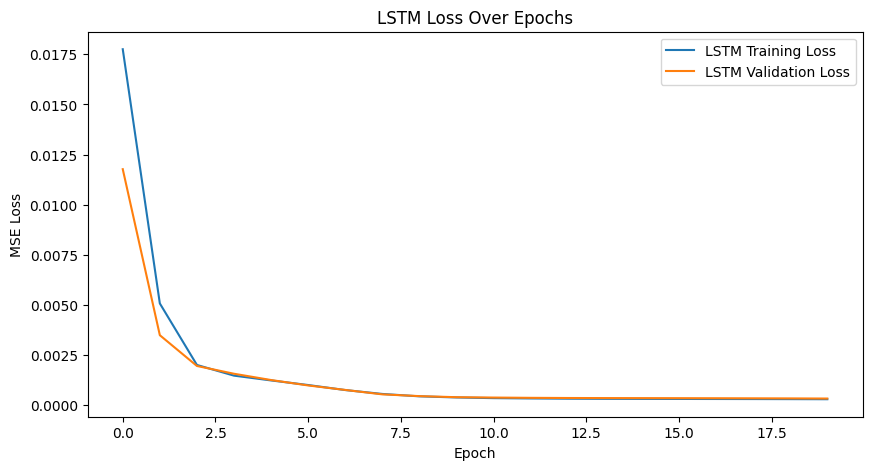

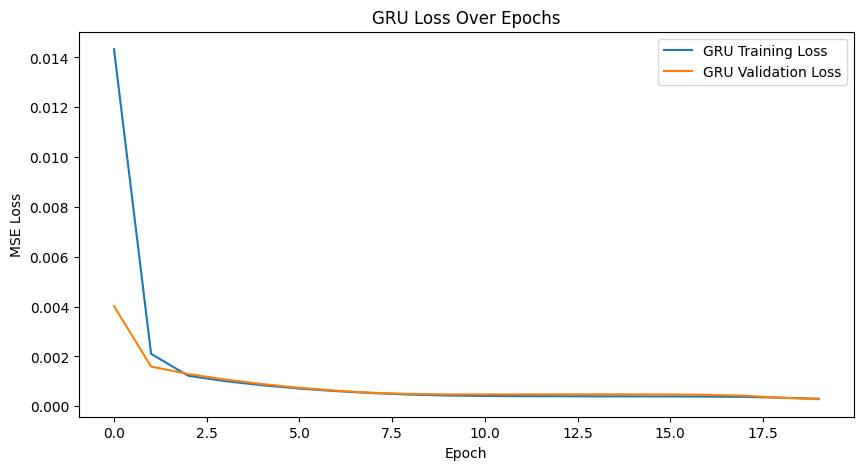

In [ ]:
#------------------------
# LSTM and GRU loss curves
#-------------------------

# LSTM
plt.figure(figsize=(10, 5))
plt.plot(lstm_train_losses, label="LSTM Training Loss")
plt.plot(lstm_val_losses, label = "LSTM Validation Loss")
plt.title("LSTM Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# GRU
plt.figure(figsize=(10, 5))
plt.plot(gru_train_losses, label="GRU Training Loss")
plt.plot(gru_val_losses, label = "GRU Validation Loss")
plt.title("GRU Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [ ]:
#----------
# Evaluation
#-----------

# LSTM
lstm_val_loss, lstm_val_preds_scaled, lstm_val_actuals_scaled = evaluate_model(lstm_model, val_loader, loss_function)
lstm_test_loss, lstm_test_preds_scaled, lstm_test_actuals_scaled = evaluate_model(lstm_model, val_loader, loss_function)

lstm_val_preds = scaler.inverse_transform(lstm_val_preds_scaled)
lstm_val_actuals = scaler.inverse_transform(lstm_val_actuals_scaled)

lstm_test_preds = scaler.inverse_transform(lstm_test_preds_scaled)
lstm_test_actuals = scaler.inverse_transform(lstm_test_actuals_scaled)

lstm_val_mse = mean_squared_error(lstm_val_actuals, lstm_val_preds)
lstm_val_rmse = np.sqrt(lstm_val_mse)
lstm_val_mae = mean_absolute_error(lstm_val_actuals, lstm_val_preds)

lstm_test_mse = mean_squared_error(lstm_test_actuals, lstm_test_preds)
lstm_test_rmse = np.sqrt(lstm_test_mse)
lstm_test_mae = mean_absolute_error(lstm_test_actuals, lstm_test_preds)

print("LSTM Validation Metrics:")
print(f"MSE: {lstm_val_mse:.4f}")
print(f"RMSE: {lstm_val_rmse:.4f}")
print(f"MAE: {lstm_val_mae:.4f}")
print("\nLSTM Test Metrics:")
print(f"MSE: {lstm_test_mse:.4f}")
print(f"RMSE: {lstm_test_rmse:.4f}")
print(f"MAE: {lstm_test_mae:.4f}")

# GRU
gru_val_loss, gru_val_preds_scaled, gru_val_actuals_scaled = evaluate_model(gru_model, val_loader, loss_function)
gru_test_loss, gru_test_preds_scaled, gru_test_actuals_scaled = evaluate_model(gru_model, val_loader, loss_function)

gru_val_preds = scaler.inverse_transform(gru_val_preds_scaled)
gru_val_actuals = scaler.inverse_transform(gru_val_actuals_scaled)

gru_test_preds = scaler.inverse_transform(gru_test_preds_scaled)
gru_test_actuals = scaler.inverse_transform(gru_test_actuals_scaled)

gru_val_mse = mean_squared_error(gru_val_actuals, gru_val_preds)
gru_val_rmse = np.sqrt(gru_val_mse)
gru_val_mae = mean_absolute_error(gru_val_actuals, gru_val_preds)

gru_test_mse = mean_squared_error(gru_test_actuals, gru_test_preds)
gru_test_rmse = np.sqrt(gru_test_mse)
gru_test_mae = mean_absolute_error(gru_test_actuals, gru_test_preds)

print("\nGRU Validation Metrics:")
print(f"MSE: {gru_val_mse:.4f}")
print(f"RMSE: {gru_val_rmse:.4f}")
print(f"MAE: {gru_val_mae:.4f}")
print("\nGRU Test Metrics:")
print(f"MSE: {gru_test_mse:.4f}")
print(f"RMSE: {gru_test_rmse:.4f}")
print(f"MAE: {gru_test_mae:.4f}")

LSTM Validation Metrics:
MSE: 432729.5312
RMSE: 657.8218
MAE: 467.9589

LSTM Test Metrics:
MSE: 432729.5312
RMSE: 657.8218
MAE: 467.9589

GRU Validation Metrics:
MSE: 381512.1875
RMSE: 617.6667
MAE: 450.1747

GRU Test Metrics:
MSE: 381512.1875
RMSE: 617.6667
MAE: 450.1747


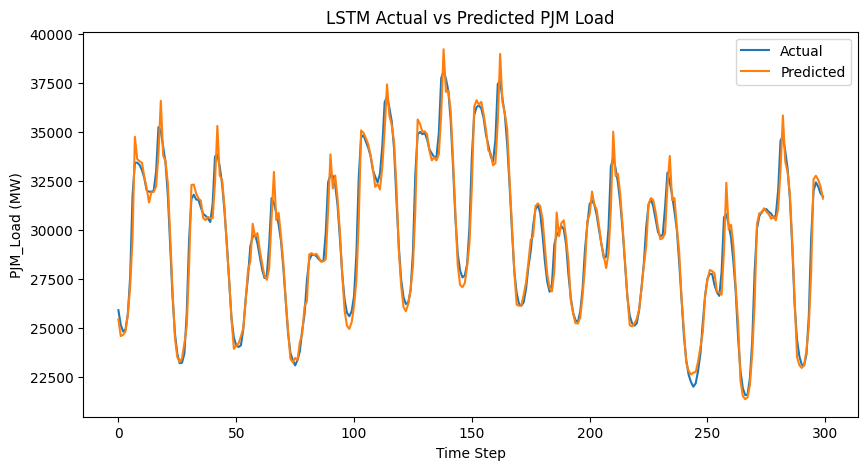

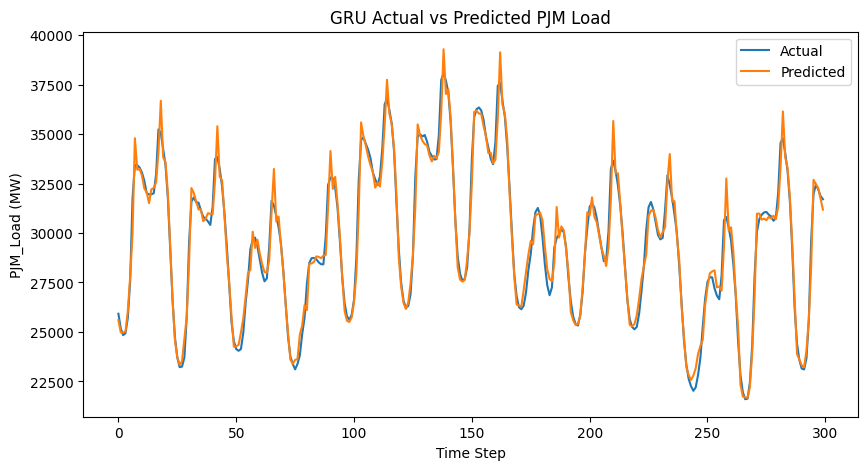

In [ ]:
#-----------------------------------------
# Predicted vs Actual Plots for Each Model
#-----------------------------------------

# LSTM
plt.figure(figsize=(10, 5))
plt.plot(lstm_test_actuals[:300], label = "Actual")
plt.plot(lstm_test_preds[:300], label="Predicted")
plt.title("LSTM Actual vs Predicted PJM Load")
plt.xlabel("Time Step")
plt.ylabel("PJM_Load (MW)")
plt.legend()
plt.show()

# GRU
plt.figure(figsize=(10, 5))
plt.plot(gru_test_actuals[:300], label = "Actual")
plt.plot(gru_test_preds[:300], label="Predicted")
plt.title("GRU Actual vs Predicted PJM Load")
plt.xlabel("Time Step")
plt.ylabel("PJM_Load (MW)")
plt.legend()
plt.show()

**Analysis**  
Predicted follows the actual nearly perfectly, but in contrast to the regular RNN, overshoots extreme highs and slightly undershoots lows.

       Model    Val RMSE     Val MAE   Test RMSE    Test MAE
0  Basic RNN  625.012575  446.366730  643.251117  473.066193
1       LSTM  657.821808  467.958923  657.821808  467.958923
2        GRU  617.666729  450.174744  617.666729  450.174744


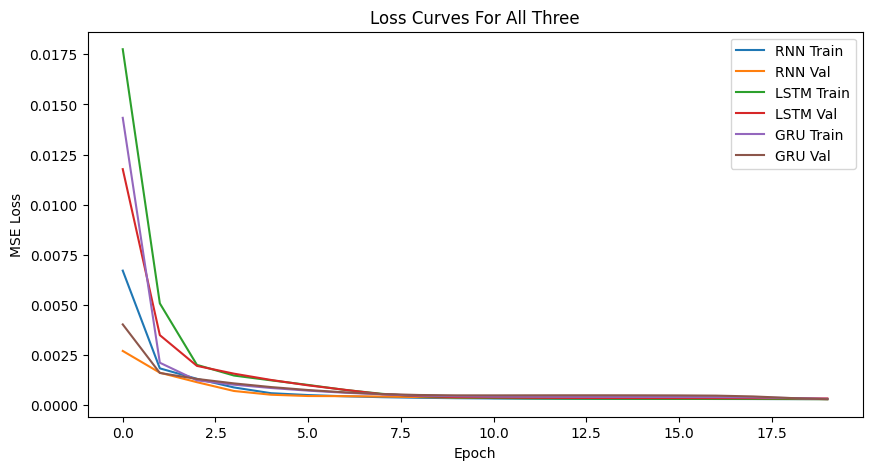

In [ ]:
#--------------------
# Combined evaluation
#--------------------

results = pd.DataFrame({
    "Model": ["Basic RNN", "LSTM", "GRU"],
    "Val RMSE": [val_rmse, lstm_val_rmse, gru_val_rmse],
    "Val MAE": [val_mae, lstm_val_mae, gru_val_mae],
    "Test RMSE": [test_rmse, lstm_test_rmse, gru_test_rmse],
    "Test MAE": [test_mae, lstm_test_mae, gru_test_mae]
})

print(results)

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="RNN Train")
plt.plot(val_losses, label = "RNN Val")
plt.plot(lstm_train_losses, label="LSTM Train")
plt.plot(lstm_val_losses, label = "LSTM Val")
plt.plot(gru_train_losses, label="GRU Train")
plt.plot(gru_val_losses, label = "GRU Val")
plt.title("Loss Curves For All Three")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

**Analysis**  
Based on RMSE (large errors), the order of best models goes 1. GRU, 2. RNN, 3. LSTM. Based on MAE (typical error), the ranking goes 1. RNN followed very closely by GRU in 2nd, and LSTM last. GRU performed best overall with RNN being a surprisingly competitive runner up, and LSTM performed the worst.
<br>
<br>
**Explanation of Differences between RNN, LSTM, and GRU**  
GRU performed better than LSTM likely because GRU is a simpler model than LSTM, and the size of the dataset (50k) may have lended itself better to the complexity of GRU than to the greater complexity of LSTU. Similarly, the sequence length was only 24 hours, which also may not have been a large enough dependency to allow LSTM's complex memory structure to outperform GRU's simpler architecture. LSTM's performance can likely just be explained by it being too complex for this specific problem.
<br>
<br>
I'm very surprised at how well the basic RNN model performed. However, this may easily be explained by how strong the energy usage patterns were in the dataset. The clear and consistent daily and seasonal cycles were likely simple enough to learn, especially coupled with the fact that the next-hour target is of a very limited range that only demands basic short-term memory. Thus, the basic RNN was able to handle the problem very well.

### Part 3

**Could you use a traditional feed-forward network?**  

Feed-forward neural networks could solve this problem, but only after converting the time-series data into a format it can process. Traditional feed-forward networks expect inputs in the form X = [feature1, feature2, feature3, ...], whereas this dataset contains only a single feature measured sequentially over time. However, the data can be made usable by feed-forward networks by having each of its past time steps converted into separate input features. For example, the input could be constructed as X = [loadt1, loadt2, loadt3, ...] where each feature represents the load from a previous hour and the target would be y = [loadt], the load at the next hour. In this way, the previous 24 hours of energy demand become 24 separate input features. Even with this adjustment, however, the feed-forward network would still treat inputs indpendently, would not be able to understnad their temporal order, and would have no internal memory to store information about historical patterns.